In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download("stopwords")
nltk.download("wordnet")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Embedding,Bidirectional,LSTM,Dense,Dropout
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

from imblearn.over_sampling import SMOTE

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
df = pd.read_csv("/kaggle/input/datasets/simaanjali/emotion-analysis-based-on-text/emotion_sentimen_dataset.csv")
df

,Unnamed: 0,text,Emotion
0,0,i seriously hate one subject to death but now ...,hate
1,1,im so full of life i feel appalled,neutral
2,2,i sit here to write i start to dig out my feel...,neutral
3,3,ive been really angry with r and i feel like a...,anger
4,4,i feel suspicious if there is no one outside l...,neutral
...,...,...,...
839550,839550,i feel like telling these horny devils to find...,neutral
839551,839551,i began to realize that when i was feeling agi...,neutral
839552,839552,i feel very curious be why previous early dawn...,neutral
839553,839553,i feel that becuase of the tyranical nature of...,neutral


In [4]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [5]:
df.tail()

,text,Emotion
839550,i feel like telling these horny devils to find...,neutral
839551,i began to realize that when i was feeling agi...,neutral
839552,i feel very curious be why previous early dawn...,neutral
839553,i feel that becuase of the tyranical nature of...,neutral
839554,i think that after i had spent some time inves...,neutral


In [6]:
df.shape

(839555, 2)

In [7]:
df.columns

Index(['text', 'Emotion'], dtype='object')

In [8]:
df.isnull().sum()

text       0
Emotion    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(445733)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Emotion"].value_counts()

Emotion
neutral       316935
love           17634
happiness      13038
sadness         8485
relief          8007
hate            6160
anger           5952
fun             4854
enthusiasm      4497
surprise        3430
empty           2697
worry           2072
boredom           61
Name: count, dtype: int64

/tmp/ipykernel_58/2004665697.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


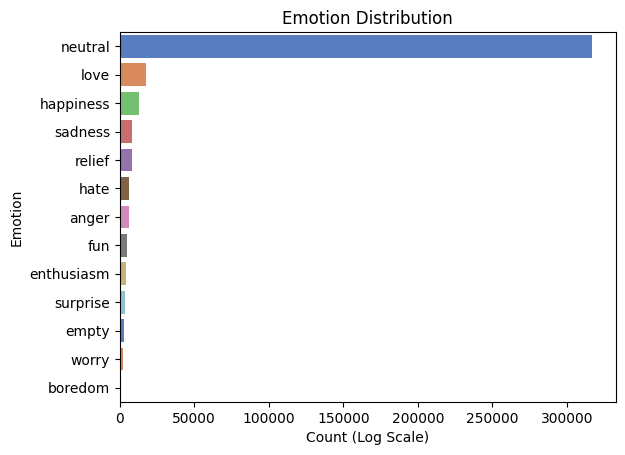

In [13]:
sns.countplot(
    y="Emotion", 
    data=df, 
    order=df['Emotion'].value_counts().index,
    palette="muted"  
)

plt.title("Emotion Distribution")
plt.xlabel("Count (Log Scale)")
plt.ylabel("Emotion")
plt.show()

In [14]:
df["text"][0]

'i seriously hate one subject to death but now i feel reluctant to drop it'

In [15]:
stop_words = set(stopwords.words("english"))

In [16]:
lemmatizer = WordNetLemmatizer()

In [17]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"<.*?>", " ", text)

    text = re.sub(r"http\S+|www\S+", " ", text)

    text = re.sub(r"\d+", " ", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)

In [18]:
df["clean_text"] = df["text"].apply(clean_text)

In [19]:
print(df["text"][0])
print(df["clean_text"][0])

i seriously hate one subject to death but now i feel reluctant to drop it
seriously hate one subject death feel reluctant drop


In [20]:
encoder = LabelEncoder()
df["Emotion_Encoded"] = encoder.fit_transform(df["Emotion"])

In [21]:
X = df["clean_text"]
y = df["Emotion_Encoded"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
print(X_train.shape)
print(X_test.shape)

(315057,)
(78765,)


In [24]:
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

In [25]:
tokenizer.fit_on_texts(X_train)

In [26]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [27]:
print(X_train.iloc[0])

feel like fine somewhere else might want polished look


In [28]:
print(X_train_seq[0])

[2, 4, 289, 873, 175, 109, 16, 7912, 54]


In [29]:
max_len = 100

In [30]:
X_train_padded = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [31]:
print(X_train_padded.shape)
print(X_test_padded.shape)

(315057, 100)
(78765, 100)


In [32]:
model = Sequential()

model.add(
    Embedding(
        input_dim=10000,
        output_dim=128,
        input_shape=(100,)
    )
)

model.add(
    Bidirectional(
        LSTM(
            units=64,
            return_sequences=False
        )
    )
)

model.add(Dropout(0.5))

model.add(Dense(13, activation="softmax"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1787219059.505201      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787219059.508228      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,380,493 (5.27 MB)

 Trainable params: 1,380,493 (5.27 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
class_weights

{np.int64(0): np.float64(5.089280522081866),
 np.int64(1): np.float64(494.5949764521193),
 np.int64(2): np.float64(11.23037712982106),
 np.int64(3): np.float64(6.735729251293454),
 np.int64(4): np.float64(6.241347887240239),
 np.int64(5): np.float64(2.323600560513312),
 np.int64(6): np.float64(4.917847777222777),
 np.int64(7): np.float64(1.7179523531689123),
 np.int64(8): np.float64(0.09558446302324164),
 np.int64(9): np.float64(3.7837867050981804),
 np.int64(10): np.float64(3.5702937310185394),
 np.int64(11): np.float64(8.832053150930703),
 np.int64(12): np.float64(14.617101234109677)}

In [36]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

history = model.fit(
    X_train_padded,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/10
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.6016 - loss: 0.7062 - val_accuracy: 0.7757 - val_loss: 0.6074 - learning_rate: 0.0010
Epoch 2/10
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9420 - loss: 0.1489 - val_accuracy: 0.9853 - val_loss: 0.1575 - learning_rate: 0.0010
Epoch 3/10
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9702 - loss: 0.0778 - val_accuracy: 0.9932 - val_loss: 0.0616 - learning_rate: 0.0010
Epoch 4/10
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9815 - loss: 0.0574 - val_accuracy: 0.9842 - val_loss: 0.0927 - learning_rate: 0.0010
Epoch 5/10
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9883 - loss: 0.0406 - val_accuracy: 0.9908 - val_loss: 0.0655 - learning_rate: 0.0010
Epoch 6/10
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9925 - loss: 0.0249 - val_accuracy: 0.9899 - val_loss: 0.0591 - learning_rate: 5.0000e-04
Epoch 7/10
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - ac

In [37]:
loss, accuracy = model.evaluate(
    X_test_padded,
    y_test
)
print("Loss :", loss)
print("Accuracy :", accuracy)

2462/2462 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9916 - loss: 0.0540
Loss : 0.054046668112277985
Accuracy : 0.9915571808815002


In [38]:
predictions = model.predict(X_test_padded)

predictions = np.argmax(predictions, axis=1)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

2462/2462 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step
Accuracy: 0.9915571637148479
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1190
           1       0.42      0.67      0.52        12
           2       0.98      0.97      0.98       539
           3       0.98      0.99      0.99       899
           4       0.88      0.96      0.92       971
           5       0.99      0.99      0.99      2608
           6       0.98      0.99      0.99      1232
           7       0.98      0.99      0.99      3527
           8       1.00      0.99      1.00     63388
           9       0.93      0.98      0.96      1602
          10       0.99      0.98      0.99      1697
          11       0.98      0.99      0.98       686
          12       0.92      0.98      0.95       414

    accuracy                           0.99     78765
   macro avg       0.92      0.96      0.94     78765
weighted avg       0.99      0.99      0.99     78765



In [39]:
import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [42]:
def predict_emotion(text):
    text_clean = clean_text(text)
    
    seq = tokenizer.texts_to_sequences([text_clean])
    seq = pad_sequences(seq, maxlen=100, padding='post', truncating='post')
    
    pred_probs = model.predict(seq, verbose=0)[0]
    
    pred_class = np.argmax(pred_probs)
    
    emotion_label = encoder.inverse_transform([pred_class])[0]
    
    confidence = pred_probs[pred_class]
    
    return emotion_label, confidence

test_reviews = [
    "I seriously hate this so much, it makes me so angry!",
    "This is absolutely wonderful, I am so full of joy and happiness!",
    "Finally, everything is clear and I feel so relaxed now."
]

for review in test_reviews:
    label, score = predict_emotion(review)
    print('-' * 60)
    print("Text:", review)
    print(f"Predicted Emotion: {label.upper()} | Score: {score*100:.2f}%")

------------------------------------------------------------
Text: I seriously hate this so much, it makes me so angry!
Predicted Emotion: HATE | Score: 99.96%
------------------------------------------------------------
Text: This is absolutely wonderful, I am so full of joy and happiness!
Predicted Emotion: HAPPINESS | Score: 99.95%
------------------------------------------------------------
Text: Finally, everything is clear and I feel so relaxed now.
Predicted Emotion: NEUTRAL | Score: 99.77%
